## BORDES

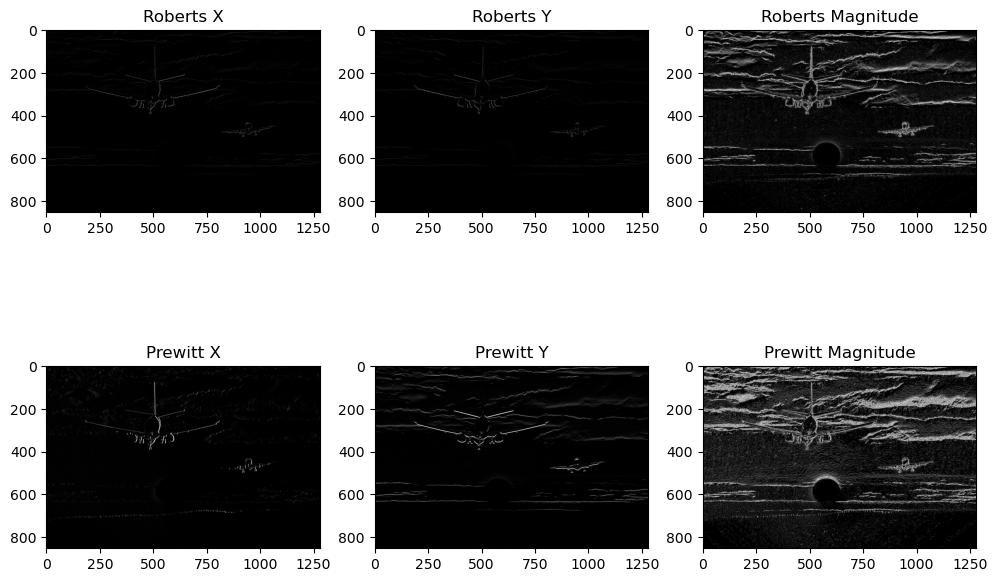

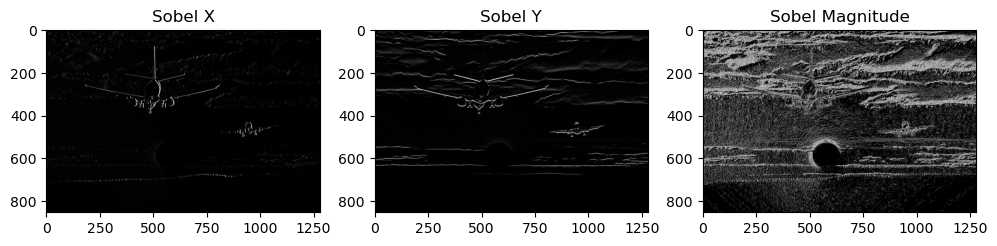

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt 
img= cv2.imread('imagen1.jpg')
gray= cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
robertx=np.array([[-1,0],[0,1]])
roberty=np.array([[0,-1],[1,0]])
robx_img=cv2.filter2D(gray,-1,robertx)
roby_img=cv2.filter2D(gray,-1,roberty)
rob_grad=np.sqrt(robx_img**2+roby_img**2)
rob_grad_dir=np.arctan2(roby_img,robx_img)

##prewit

prewitt_x=np.array([[-1,0,1],[-1,0,1],[-1,0,1]])
prewitt_y=np.array([[-1,-1,-1],[0,0,0],[1,1,1]])
prex_img= cv2.filter2D(gray,-1,prewitt_x)
prey_img= cv2.filter2D(gray,-1,prewitt_y)
prewitt_mag=np.sqrt(prex_img**1+prey_img**2)
prewitt_dir=np.arctan2(prey_img,prex_img)

##sobel
sobel_x=np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
sobel_y=np.array([[-1,-2,-1],[0,0,0],[1,2,1]])
sobelx_img=cv2.filter2D(gray,-1,sobel_x)
sobely_img=cv2.filter2D(gray,-1,sobel_y)
sobel_mag=np.sqrt(sobelx_img**2+sobely_img**2)
sobel_dir=np.arctan2(sobely_img,sobelx_img)

plt.figure(figsize=(12,8))
plt.subplot(2,3,1)
plt,plt.imshow(robx_img,cmap='gray')
plt.title('Roberts X')


plt.subplot(2,3,2)
plt.imshow(roby_img,cmap='gray')
plt.title('Roberts Y')

plt.subplot(2,3,3)
plt.imshow(rob_grad,cmap='gray')
plt.title('Roberts Magnitude')

plt.subplot(2,3,4)
plt.imshow(prex_img,cmap='gray')
plt.title('Prewitt X')

plt.subplot(2,3,5)
plt.imshow(prey_img,cmap='gray')
plt.title('Prewitt Y')

plt.subplot(2,3,6)
plt.imshow(prewitt_mag,cmap='gray')
plt.title('Prewitt Magnitude')

plt.figure(figsize=(12,8))
plt.subplot(2,3,1)  
plt.imshow(sobelx_img,cmap='gray')
plt.title('Sobel X')

plt.subplot(2,3,2)
plt.imshow(sobely_img,cmap='gray')
plt.title('Sobel Y')

plt.subplot(2,3,3)
plt.imshow(sobel_mag,cmap='gray')
plt.title('Sobel Magnitude')
plt.show()


## SOBEL

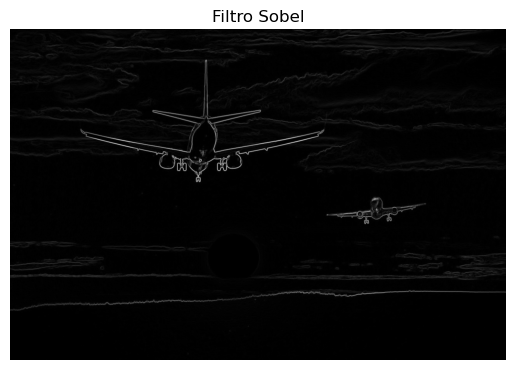

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt 

def filtro_sobel(img):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    g_x = cv2.Sobel(img_gris, cv2.CV_64F, 1, 0, ksize=3)
    g_y = cv2.Sobel(img_gris, cv2.CV_64F, 0, 1, ksize=3)

    mag=np.sqrt(np.square(g_x)+np.square(g_y))
    mag=cv2.normalize(mag,None,0,255,cv2.NORM_MINMAX,cv2.CV_8U)
    return mag

img = cv2.imread('imagen1.jpg')
sobel_result = filtro_sobel(img)
plt.imshow(sobel_result, cmap='gray')
plt.title('Filtro Sobel')
plt.axis('off')
plt.show()


## SOBEL MEJORADO

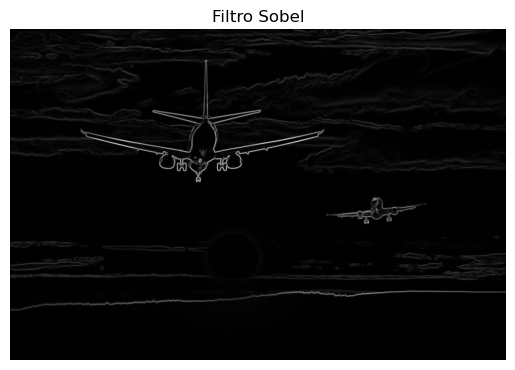

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt 

def filtro_sobel_mejorado(img,kernel_size=3,umbral=30):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    #para mejorar la deteccion filtro gaussiano
    img_gris = cv2.GaussianBlur(img_gris,(3,3),0)

    g_x = cv2.Sobel(img_gris, cv2.CV_64F, 1, 0, ksize=3)
    g_y = cv2.Sobel(img_gris, cv2.CV_64F, 0, 1, ksize=3)

    ## mag=np.sqrt(np.square(g_x)+np.square(g_y))
    mag=np.sqrt(g_x**2 + g_y**2)
    mag=cv2.normalize(mag,None,0,255,cv2.NORM_MINMAX,cv2.CV_8U)
    _,bordes=cv2.threshold(mag,umbral,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    #OPERACION MORPH UNIR BORDES ROTOS
    kernel_m=np.ones((2,2),np.uint8)
    kbordes=cv2.morphologyEx(bordes,cv2.MORPH_CLOSE,kernel_m)
    return mag

img = cv2.imread('imagen1.jpg')
sobel_result = filtro_sobel_mejorado(img)
plt.imshow(sobel_result, cmap='gray')
plt.title('Filtro Sobel')
plt.axis('off')
plt.show()



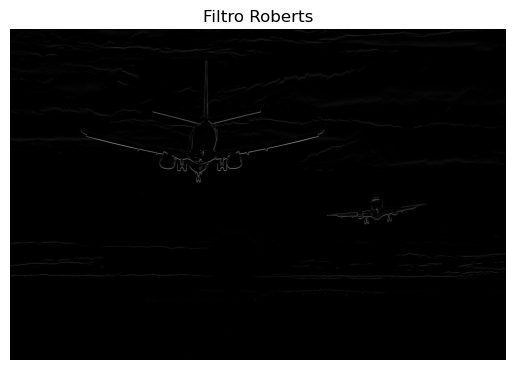

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt 

def filtro_roberts(img):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    robertx=np.array([[-1,0],[0,1]],dtype=np.float32)
    roberty=np.array([[0,-1],[1,0]],dtype=np.float32)
    r_x=cv2.filter2D(img_gris,-1,robertx)
    r_y=cv2.filter2D(img_gris,-1,roberty)
    roberts=cv2.addWeighted(r_x,0.5,r_y,0.5,0)
    return roberts
img = cv2.imread('imagen1.jpg')
roberts_result = filtro_roberts(img)
plt.imshow(roberts_result, cmap='gray')
plt.title('Filtro Roberts')
plt.axis('off')
plt.show()
